In [ ]:
# Importi i Postavljanje okruženja

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import xgboost as xgb
import shap

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

# Postavke za grafove
%matplotlib inline
sns.set_theme(style="whitegrid")

In [ ]:
# Učitavanje i Feature Engineering
# Ovdje čistimo podatke i stvaramo logične varijable poput "starosti kuće".

In [2]:
df = pd.read_csv(r'C:\Users\x\Desktop\diplomski_projekt\Housing.csv')

# 1. Transformacija datuma u starost i kreiranje binarne varijable za renovaciju
df['date'] = pd.to_datetime(df['date'])
df['house_age'] = df['date'].dt.year - df['yr_built']
df['renovated'] = df['yr_renovated'].apply(lambda x: 1 if x > 0 else 0)

# 2. Uklanjanje kolona koje bi zbunile model (ID i Zipcode previše šire dimenzije)
df = df.drop(columns=['id', 'date', 'zipcode'])

# 3. Definiranje cilja (y) i prediktora (X)
X = df.drop('price', axis=1)
y = df['price']

# 4. Skaliranje podataka (Ključno za Neuronsku mrežu)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Podjela na trening i test skup
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Dataset spreman. Broj značajki: {X_train.shape[1]}")

Dataset spreman. Broj značajki: 19


In [ ]:
# Eksploratorna Analiza Podataka (EDA)

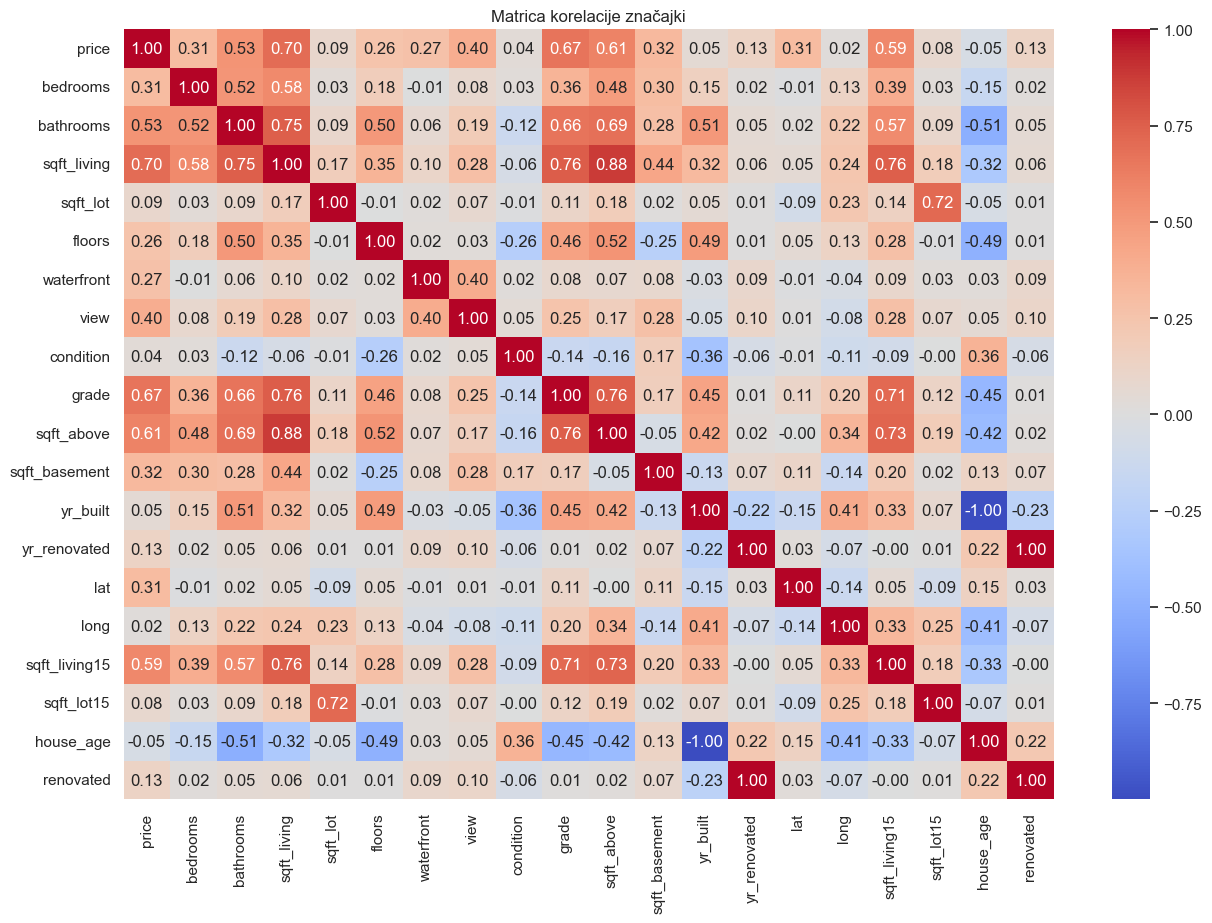

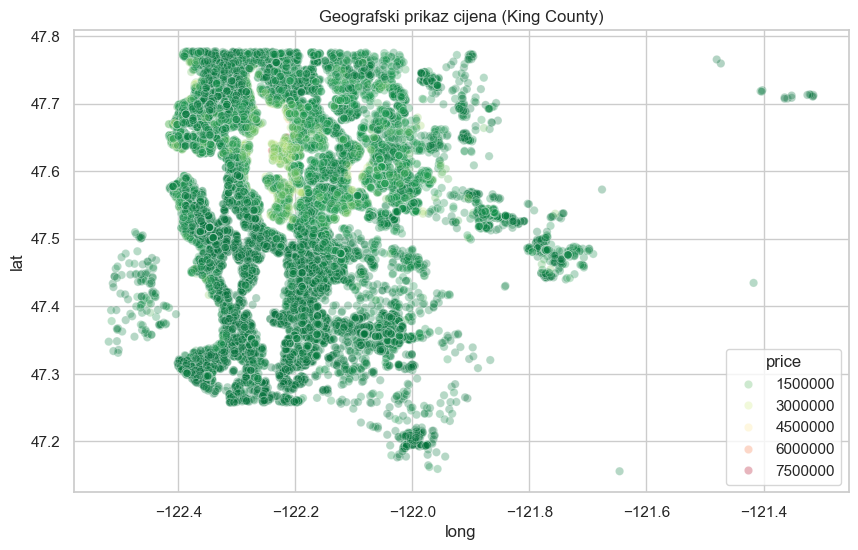

In [3]:
# Heatmap korelacije
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrica korelacije značajki')
plt.show()

# Geografska distribucija cijena
plt.figure(figsize=(10, 6))
sns.scatterplot(x='long', y='lat', data=df, hue='price', palette='RdYlGn_r', alpha=0.3)
plt.title('Geografski prikaz cijena (King County)')
plt.show()

In [ ]:
# Treniranje Modela

In [4]:
# Klasični ML (LR & Random Forest)
lr = LinearRegression()
lr.fit(X_train, y_train)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [5]:
# XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [6]:
# Artificial Neural Network (ANN)
ann_model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

ann_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = ann_model.fit(X_train, y_train, validation_split=0.2, epochs=100, batch_size=32, callbacks=[early_stop], verbose=0)

136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
               Model            MAE           RMSE        R2
2            XGBoost   71896.513847  137157.520180  0.875562
1      Random Forest   73578.826790  152266.371033  0.846636
3     Neural Network  106222.262932  181392.770306  0.782352
0  Linear Regression  127232.747128  213445.804037  0.698637


C:\Users\x\AppData\Local\Temp\ipykernel_25116\816824243.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2', data=results_df, palette='viridis')


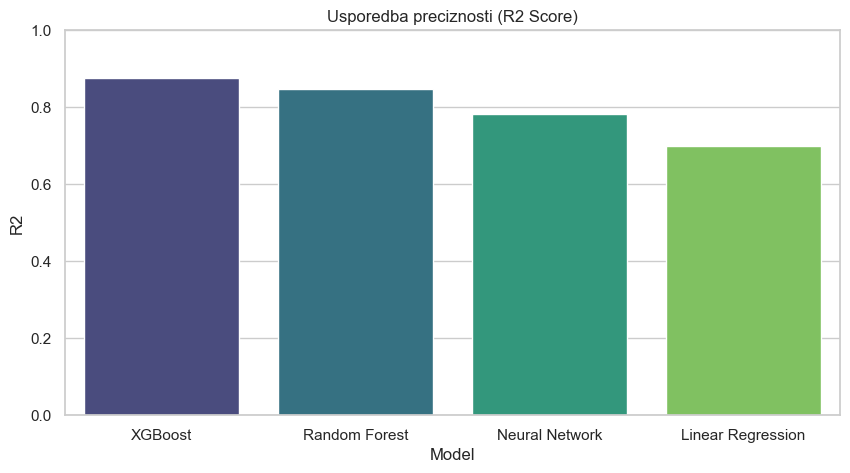

In [7]:
# Evaluacija i Usporedba Rezultata
def get_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

# Predikcije
pred_lr = lr.predict(X_test)
pred_rf = rf.predict(X_test)
pred_xgb = xgb_model.predict(X_test)
pred_ann = ann_model.predict(X_test).flatten()

# Tablica rezultata
final_results = [
    get_metrics(y_test, pred_lr, "Linear Regression"),
    get_metrics(y_test, pred_rf, "Random Forest"),
    get_metrics(y_test, pred_xgb, "XGBoost"),
    get_metrics(y_test, pred_ann, "Neural Network")
]

results_df = pd.DataFrame(final_results).sort_values(by='R2', ascending=False)
print(results_df)

# Grafikon usporedbe
plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='R2', data=results_df, palette='viridis')
plt.title('Usporedba preciznosti (R2 Score)')
plt.ylim(0, 1)
plt.show()

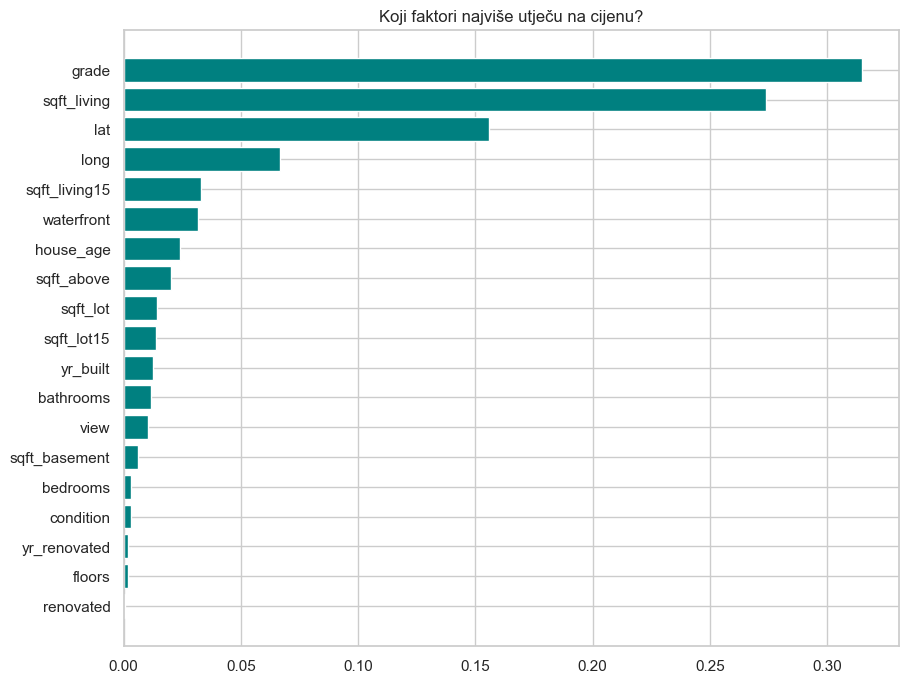

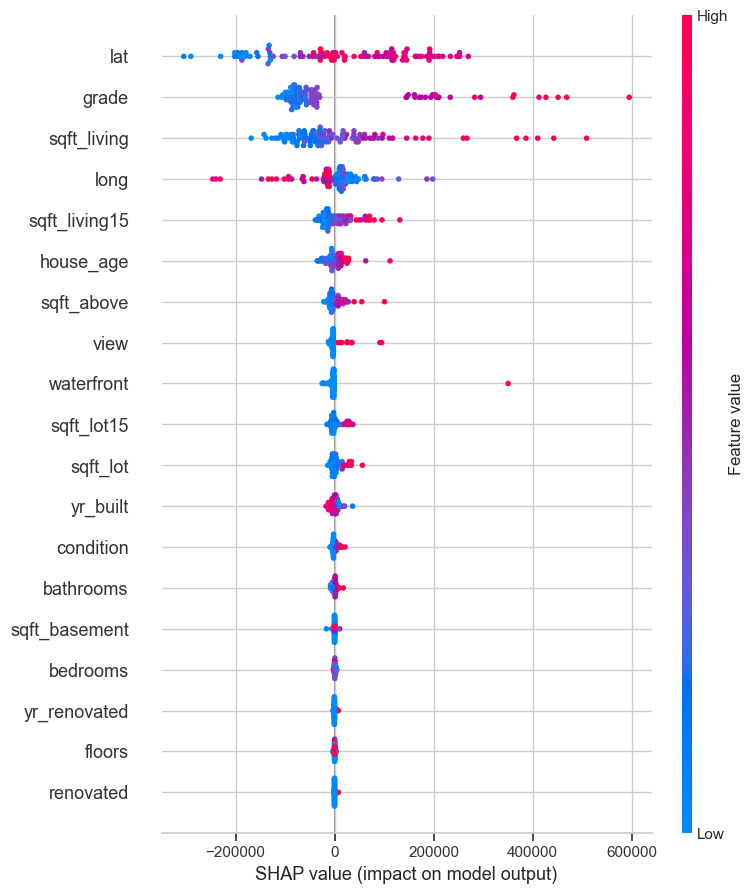

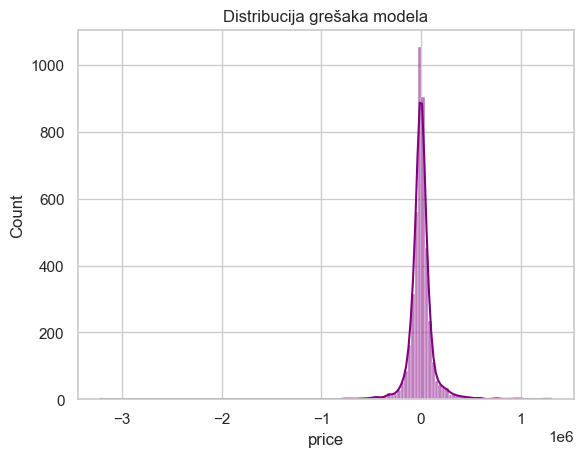

In [8]:
# Napredna analiza
# 1. Važnost značajki (Random Forest)
importances = rf.feature_importances_
indices = np.argsort(importances)
plt.figure(figsize=(10, 8))
plt.barh(range(len(indices)), importances[indices], color='teal')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.title('Koji faktori najviše utječu na cijenu?')
plt.show()

# 2. SHAP Analiza (Interpretacija procesa odlučivanja)
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test[:100])
shap.summary_plot(shap_values, X_test[:100], feature_names=X.columns)

# 3. Analiza reziduala (Grešaka)
residuals = y_test - pred_rf
sns.histplot(residuals, kde=True, color='purple')
plt.title('Distribucija grešaka modela')
plt.show()

In [9]:
# Error Analiza (Top 5 promašaja)
error_analysis = pd.DataFrame(X_test, columns=X.columns)
error_analysis['Stvarna_Cijena'] = y_test.values
error_analysis['Predvidena_Cijena'] = pred_rf
error_analysis['Abs_Greska'] = np.abs(error_analysis['Stvarna_Cijena'] - error_analysis['Predvidena_Cijena'])

top_errors = error_analysis.sort_values(by='Abs_Greska', ascending=False).head(5)
print("Analiza najvećih odstupanja:")
print(top_errors[['Stvarna_Cijena', 'Predvidena_Cijena', 'Abs_Greska', 'sqft_living', 'grade']])

Analiza najvećih odstupanja:
      Stvarna_Cijena  Predvidena_Cijena  Abs_Greska  sqft_living     grade
2505        800000.0         4019415.00  3219415.00     5.879774  2.844170
3275       2280000.0         5473649.00  3193649.00    12.478065  3.694921
4217       2888000.0         5206049.00  2318049.00     7.175478  4.545672
1327        900000.0         2402807.50  1502807.50     5.487797  3.694921
1283       2205000.0          897541.38  1307458.62     1.470025  1.993418
